In [1]:
import pandas as pd
import os
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve,
                              average_precision_score, f1_score)
import matplotlib.pyplot as plt

base_path = os.path.join(os.getcwd(), "..", "data")
processed_path = os.path.join(base_path, "processed")

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:

all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)
all_data['group_id'] = all_data['dataset_type'] + '_' + all_data['scenario_id'].astype(str)

feature_cols = sorted(['cpu_usage', 'mem_usage', 'disk_io', 'net_in', 'net_out'])
X      = all_data[feature_cols]
y      = all_data['label']
groups = all_data['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
meta_test_rows = all_data[['dataset_type', 'scenario_id', 'case_id']].iloc[test_idx].reset_index(drop=True)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

# P4 trainiert beide Modelle neu auf denselben Splits um sicherzustellen,
# dass XGBoost und LogReg exakt dieselben Train-Cases gesehen haben (kein Split-Leakage)
model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=neg/pos, tree_method='hist',
    eval_metric='aucpr', early_stopping_rounds=20,
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_proba_rows = model.predict_proba(X_test)[:, 1]
_, recalls_p2, thresholds_p2 = precision_recall_curve(y_test, y_proba_rows)
valid_t2 = thresholds_p2[recalls_p2[:-1] >= 0.95]
threshold_p2 = float(valid_t2.max()) if len(valid_t2) > 0 else float(thresholds_p2[0])

# Aggregation auf Case-Ebene: max_proba pro Case
meta_test_rows['proba_xgb'] = y_proba_rows
meta_test_rows['label']     = y_test.values

case_metric = (meta_test_rows
               .groupby('case_id')
               .agg(max_proba=('proba_xgb', 'max'), # max-Aggregation: ein Peak genügt
                    label=('label', 'max'), # label ist pro Case konstant (alle Zeilen gleich)
                    dataset_type=('dataset_type', 'first'),
                    scenario_id=('scenario_id', 'first'))
               .reset_index())

case_metric['metric_trigger'] = (case_metric['max_proba'] >= threshold_p2).astype(int)

print(f"Threshold P2:             {threshold_p2:.4f}")
print(f"Cases im P2-Test:         {len(case_metric)}")
print(f"metric_trigger=1:         {case_metric['metric_trigger'].sum()}")
print(f"metric_trigger=0 (neg):   {(case_metric['metric_trigger'] == 0).sum()}")

Threshold P2:             0.0222
Cases im P2-Test:         253
metric_trigger=1:         252
metric_trigger=0 (neg):   1


In [3]:
# Log-Texte für dieselben Cases laden
def load_log_text(row):
    """Lädt den Syslog-Text einer .log-Datei anhand von dataset_type/scenario_id/case_id.
    Gibt leeren String zurück wenn Datei fehlt (kein Case wird verworfen)."""
    log_filename = row['case_id'].replace('.csv', '.log')
    log_path = os.path.join(base_path, f"{row['dataset_type']}_dataset",
                            row['scenario_id'], log_filename)
    if os.path.exists(log_path):
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return ""

# Train-Cases für TF-IDF fit
train_cases_ids = set(all_data.iloc[train_idx]['case_id'])
test_cases_ids  = set(case_metric['case_id'])

# Alle Case-Metadaten
all_cases = (all_data
             .drop_duplicates(subset='case_id')[['case_id', 'scenario_id', 'dataset_type', 'label']]
             .reset_index(drop=True))
all_cases['log_text'] = all_cases.apply(load_log_text, axis=1)

train_cases_df = all_cases[all_cases['case_id'].isin(train_cases_ids)]
test_cases_df  = all_cases[all_cases['case_id'].isin(test_cases_ids)]

# TF-IDF — fit nur auf Train
vectorizer = TfidfVectorizer(
    max_features=10000, ngram_range=(1,2),
    sublinear_tf=True, min_df=2
)
X_train_tfidf = vectorizer.fit_transform(train_cases_df['log_text'])
X_test_tfidf  = vectorizer.transform(test_cases_df['log_text'])

# class_weight='balanced' übernimmt die Gewichtung — neg_c/pos_c nicht benötigt
neg_c = (train_cases_df['label'] == 0).sum()  # zur Dokumentation: 824 negativ
pos_c = (train_cases_df['label'] == 1).sum()  # zur Dokumentation: 175 positiv

log_reg = LogisticRegression(
    class_weight='balanced', max_iter=1000,
    random_state=42, solver='lbfgs', C=1.0
)
log_reg.fit(X_train_tfidf, train_cases_df['label'])

# Predictions
y_proba_log = log_reg.predict_proba(X_test_tfidf)[:, 1]

_, recalls_log, thresholds_log = precision_recall_curve(test_cases_df['label'], y_proba_log)
valid_tl = thresholds_log[recalls_log[:-1] >= 0.95]
threshold_log = float(valid_tl.max()) if len(valid_tl) > 0 else float(thresholds_log[0])

test_cases_df = test_cases_df.copy()
test_cases_df['proba_log'] = y_proba_log
test_cases_df['log_trigger'] = (y_proba_log >= threshold_log).astype(int)

print(f"Threshold Log:    {threshold_log:.4f}")
print(f"log_trigger=1:    {test_cases_df['log_trigger'].sum()}")
print(f"log_trigger=0:    {(test_cases_df['log_trigger'] == 0).sum()}")

Threshold Log:    0.1923
log_trigger=1:    100
log_trigger=0:    153


In [4]:
fusion = case_metric.merge(
    test_cases_df[['case_id', 'proba_log', 'log_trigger']],
    on='case_id', how='inner'
)

assert len(fusion) == 253, f"Case-Mismatch: {len(fusion)}"
print(f"Fusion Cases: {len(fusion)} — Alignment OK")


# AND-Gate: Alert nur wenn metric_trigger=1 UND log_trigger=1
fusion['alert'] = ((fusion['metric_trigger'] == 1) & (fusion['log_trigger'] == 1)).astype(int)

# Soft Score für PR-Kurve: Produkt beider Wahrscheinlichkeiten
fusion['score_fusion'] = fusion['max_proba'] * fusion['proba_log']

fusion.to_csv("../docs/fusion_cases.csv", index=False)

y_true  = fusion['label']
y_pred  = fusion['alert']
y_score = fusion['score_fusion']

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
precision_at_t = tp / (tp + fp) if (tp + fp) > 0 else 0
ap_fusion = average_precision_score(y_true, y_score)

print(f"\n=== Phase 4: AND-Fusion Ergebnisse ===")
print(f"AP (soft score):         {ap_fusion:.4f}")
print(f"Recall:                  {recall_score(y_true, y_pred):.4f}")
print(f"Precision @ threshold:   {precision_at_t:.4f}")
print(f"F1:                      {f1_score(y_true, y_pred):.4f}")
print(f"FPR gesamt:              {fp / (fp + tn):.4f}  ({fp} FP von {fp+tn})")

Fusion Cases: 253 — Alignment OK

=== Phase 4: AND-Fusion Ergebnisse ===
AP (soft score):         0.5759
Recall:                  0.9583
Precision @ threshold:   0.4600
F1:                      0.6216
FPR gesamt:              0.2634  (54 FP von 205)


In [5]:
# FPR getrennt nach anom und norm — prüft ob AND-Fusion zwischen
# technischen Anomalien (anom) und täuschend normalen Szenarien (norm) unterscheidet
for dtype in ['anom', 'norm']:
    mask = (fusion['dataset_type'] == dtype).values
    fp_sub = fusion['alert'][mask].sum()
    total_neg = (fusion['label'][mask] == 0).sum()
    print(f"FPR {dtype}: {fp_sub/total_neg:.4f}  ({fp_sub} FP von {total_neg})")

FPR anom: 0.2368  (18 FP von 76)
FPR norm: 0.2791  (36 FP von 129)


In [6]:
# Latenz-Messung P2 + P3 sequentiell (Fusion = Summe)
t0 = time.time()
_ = model.predict_proba(X_test)[:, 1]
latency_p2 = (time.time() - t0) * 1000

t0 = time.time()
_ = log_reg.predict_proba(X_test_tfidf)[:, 1]
latency_p3 = (time.time() - t0) * 1000

print(f"Latenz P2 (XGBoost):      {latency_p2:.1f} ms  ({X_test.shape[0]} Rows)")
print(f"Latenz P3 (LogReg):       {latency_p3:.1f} ms  ({X_test_tfidf.shape[0]} Cases)")
print(f"Latenz P4 Fusion (P2+P3): {latency_p2 + latency_p3:.1f} ms  (sequentiell)")

Latenz P2 (XGBoost):      37.5 ms  (22770 Rows)
Latenz P3 (LogReg):       2.7 ms  (253 Cases)
Latenz P4 Fusion (P2+P3): 40.2 ms  (sequentiell)


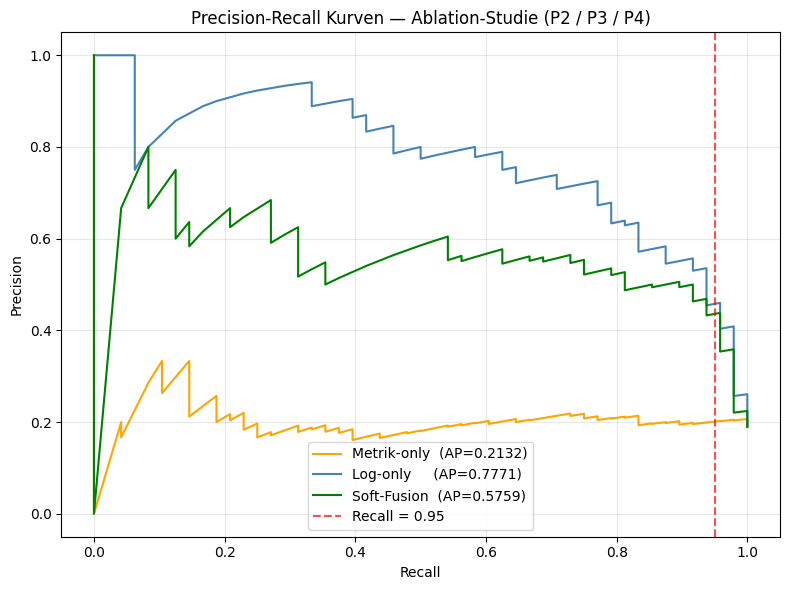

Gespeichert: pr_curve_ablation.png


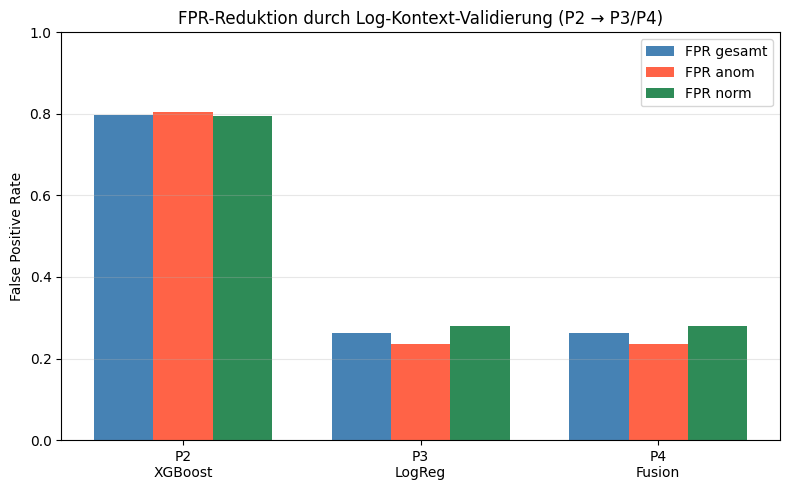

Gespeichert: fpr_comparison.png


In [7]:
plots_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(plots_path, exist_ok=True)

# --- Plot 1: Ablation — PR-Kurven aller drei Systeme ---
prec_m, rec_m, _ = precision_recall_curve(fusion['label'], fusion['max_proba'])
prec_l, rec_l, _ = precision_recall_curve(fusion['label'], fusion['proba_log'])
prec_h, rec_h, _ = precision_recall_curve(fusion['label'], fusion['score_fusion'])

ap_m = average_precision_score(fusion['label'], fusion['max_proba'])
ap_l = average_precision_score(fusion['label'], fusion['proba_log'])

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_m, prec_m, label=f'Metrik-only  (AP={ap_m:.4f})', color='orange')
ax.plot(rec_l, prec_l, label=f'Log-only     (AP={ap_l:.4f})', color='steelblue')
ax.plot(rec_h, prec_h, label=f'Soft-Fusion  (AP={ap_fusion:.4f})', color='green')
ax.axvline(x=0.95, color='red', linestyle='--', alpha=0.7, label='Recall = 0.95')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurven — Ablation-Studie (P2 / P3 / P4)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, "pr_curve_ablation.png"), dpi=150)
plt.show()
print("Gespeichert: pr_curve_ablation.png")

# --- Plot 2: FPR-Vergleich P2 / P3 / P4 ---
phases  = ['P2\nXGBoost', 'P3\nLogReg', 'P4\nFusion']
# Hardcoded aus P2/P3-Ergebnissen — stellt sicher dass Balkenplot
# reproduzierbar ist unabhängig von Notebook-Ausführungsreihenfolge
fpr_all  = [0.7980, 0.2634, 0.2634]
fpr_anom = [0.8040, 0.2368, 0.2368]
fpr_norm = [0.7940, 0.2791, 0.2791]

x = np.arange(len(phases)); w = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, fpr_all,  w, label='FPR gesamt', color='steelblue')
ax.bar(x,     fpr_anom, w, label='FPR anom',   color='tomato')
ax.bar(x + w, fpr_norm, w, label='FPR norm',   color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(phases)
ax.set_ylabel('False Positive Rate'); ax.set_ylim(0, 1.0)
ax.set_title('FPR-Reduktion durch Log-Kontext-Validierung (P2 → P3/P4)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, "fpr_comparison.png"), dpi=150)
plt.show()
print("Gespeichert: fpr_comparison.png")